In [ ]:
from google.colab import files

uploaded = files.upload()


Import & Config chung


In [2]:
!pip install pyvi
import os, re, random, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from pyvi import ViTokenizer
from typing import Set, List
import os, re, json, unicodedata, random, math
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, get_linear_schedule_with_warmup)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATA_PATH = "data.csv"
OUT_DIR = "/content/xlmr_sent3_out"; os.makedirs(OUT_DIR, exist_ok=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.3 MB/s eta 0:00:00
Device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Chuẩn hoá văn bản & Đọc dữ liệu


In [4]:
URL_RE     = re.compile(r'https?://\S+|www\.\S+', re.IGNORECASE)
USER_RE    = re.compile(r'@[A-Za-z0-9_]+')
EMAIL_RE   = re.compile(r'\b[\w.+-]+@[\w-]+\.[\w.-]+\b')
PHONE_RE   = re.compile(r'\b(?:\+?84|0)(?:[1-9]\d){8,10}\b')
MONEY_RE   = re.compile(r'(\d+[.,]?\d*)\s?(k|nghìn|ngan|ngàn|tr|triệu|m|đ|vnd)\b', re.IGNORECASE)
PERCENT_RE = re.compile(r'\b\d+[.,]?\d*\s?%\b')
NUMBER_RE  = re.compile(r'\b\d+[.,]?\d*\b')

ZW_NBSP_RE = re.compile(r'[\u200b\xa0]')
MULTI_SPACE= re.compile(r'\s+')
REPEAT_CHAR= re.compile(r'(.)\1{2,}', re.DOTALL)

#Emoji
EMOJI_ALL_RE = re.compile(
    "["
    + "\U0001F600-\U0001F64F"  # Emoticons
    + "\U0001F300-\U0001F5FF"  # Symbols & Pictographs
    + "\U0001F680-\U0001F6FF"  # Transport & Map
    + "\U0001F1E0-\U0001F1FF"  # Flags
    + "\U00002702-\U000027B0"  # Dingbats
    + "\U000024C2-\U0001F251"  # Enclosed
    + "\U0001F926-\U0001F937"
    + "\U00010000-\U0010FFFF"  # Plane 1+
    + "\u200d" + "\u2640-\u2642" + "\u2600-\u2B55" + "\u23cf" + "\u23e9" + "\u231a" + "\u3030" + "\ufe0f"
    + "]",
    re.UNICODE
)

VS16_RE      = re.compile("\ufe0f")
SKIN_TONE_RE = re.compile("[" + "\U0001F3FB-\U0001F3FF" + "]")
ZWJ_RE       = re.compile("\u200d")

LAUGH_RE = re.compile(r"(=+\)+|\)+\)+|ha(?:ha)+|hi(?:hi)+|kkk+|hu+hu+|h(?:ì|í)+h(?:ì|í)+)", re.IGNORECASE)
EMO_POS_RE = re.compile(
    r"("
    r"[" r"\U0001F600-\U0001F606" r"\U0001F60A" r"\U0001F60D" r"\U0001F642" r"\U0001F929" r"\U0001F970" r"\U0001F618" r"\u263A" r"]"
    r"|(?:\u2764\ufe0f|\u2764)"
    r"|\U0001F44D|\U0001F44C"
    r"|:D|:d|:\)+|\^\^|=+\)+|:v"
    r")",
    re.UNICODE
)
EMO_NEG_RE = re.compile(
    r"("
    r"[" r"\U0001F61E" r"\U0001F61F" r"\U0001F620" r"\U0001F621" r"\U0001F622" r"\U0001F62D" r"\U0001F494" r"\U0001F641" r"\u2639" r"]"
    r"|\U0001F44E|:\(|=\(+|T_T|>\\.<"
    r")",
    re.UNICODE
)
EMO_NEU_RE = re.compile(r"[" r"\U0001F610" r"\U0001F611" r"\U0001F636" r"\U0001F914" r"\U0001F644" r"]", re.UNICODE)

PUNCT_KEEP = "!?…"
PUNCT_RE   = re.compile(rf"[^\w\s{PUNCT_KEEP}]")
EXCLAM_RE  = re.compile(r"!{2,}")
QUEST_RE   = re.compile(r"\?{2,}")

NEGS = {"không", "chẳng", "chả", "ko", "kh"}

#Teencode
def load_teencode_regex_list(path="/content/drive/MyDrive/data/teencode.txt"):
    pairs = []
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            for ln in f.read().splitlines():
                if not ln.strip(): continue
                parts = ln.split("\t")
                if len(parts) >= 2:
                    src, dst = parts[0].strip(), parts[1].strip()
                    if src:
                        pairs.append((re.compile(rf"\b{re.escape(src)}\b", re.IGNORECASE), dst))
    else:
        fallback = {
            "ko":"không","k":"không","kh":"không","hok":"không","hong":"không","hk":"không",
            "dc":"được","đc":"được","ms":"mới","ng":"người","trc":"trước","mik":"mình","vs":"với",
            "thik":"thích","bt":"bình_thường","ntn":"như_thế_nào","sp":"sản_phẩm","ok":"okay","oke":"okay",
            "vl":"rất","vkl":"rất"
        }
        for src, dst in fallback.items():
            pairs.append((re.compile(rf"\b{re.escape(src)}\b", re.IGNORECASE), dst))
    return pairs

TEENCODE_REGEX = load_teencode_regex_list("teencode.txt")

#Stopwords
def load_stopwords(path: str = "/content/drive/MyDrive/data/vietnamese_stopwords.txt") -> Set[str]:
    """Load stopwords from file, fallback to minimal set"""
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            return set(line.strip() for line in f if line.strip())
    else:
        return {
            'thì', 'là', 'mà', 'có', 'với', 'được', 'này', 'kia', 'ấy', 'vậy',
            'về', 'nên', 'sẽ', 'đã', 'cũng', 'vẫn', 'vào', 'ra', 'lên', 'xuống',
            'nào', 'ai', 'gì', 'nơi', 'hãy', 'đừng', 'chớ', 'rất', 'quá', 'lắm'
        }

STOPWORDS = load_stopwords()

# Helpers
def _nfc(s: str) -> str:
    return unicodedata.normalize("NFC", str(s))

def _squash_repeats(s: str) -> str:
    return REPEAT_CHAR.sub(r"\1\1", s)

def _replace_special_tokens(s: str) -> str:
    s = URL_RE.sub(' __url__ ', s)
    s = EMAIL_RE.sub(' __email__ ', s)
    s = PHONE_RE.sub(' __phone__ ', s)
    s = PERCENT_RE.sub(' __percent__ ', s)
    s = MONEY_RE.sub(' __money__ ', s)
    s = NUMBER_RE.sub(' __num__ ', s)
    s = USER_RE.sub(' __user__ ', s)
    return s

def _apply_teencode(s: str) -> str:
    for rgx, rep in TEENCODE_REGEX:
        s = rgx.sub(rep, s)
    return s

def _tag_emojis(s: str) -> str:
    t = normalize_emoji_variants(s)
    t = LAUGH_RE.sub(" __laugh__ ", t)
    t = EMO_POS_RE.sub(" __emo_pos__ ", t)
    t = EMO_NEG_RE.sub(" __emo_neg__ ", t)
    t = EMO_NEU_RE.sub(" __emo_neu__ ", t)
    return t

def normalize_emoji_variants(s: str) -> str:
    s = VS16_RE.sub("", s)
    s = SKIN_TONE_RE.sub("", s)
    s = ZWJ_RE.sub("", s)
    return s

def join_negation(text: str, window: int = 1) -> str:
    toks, out, i = text.split(), [], 0
    bad = {"__emo_pos__","__emo_neg__","__url__","__email__","__percent__","__money__","__num__","__user__"}
    while i < len(toks):
        w = toks[i]
        if w in NEGS and i + 1 < len(toks):
            nxt = toks[i+1]
            if nxt not in bad and not any(ch in nxt for ch in "!?."):
                out.append(w + "_" + nxt)
                i += 2
                continue
        out.append(w); i += 1
    return " ".join(out)

def _remove_stopwords(tokens: List[str]) -> List[str]:
    """Remove stopwords while preserving special tokens"""
    return [t for t in tokens if t not in STOPWORDS or t.startswith('__')]

# Hàm chuẩn hóa
def normalize_text(
    s: str,
    keep_all_emojis: bool = False,
    use_vitok: bool = True,
    remove_stopwords_flag: bool = False
) -> str:
    s = _nfc(s)
    s = ZW_NBSP_RE.sub(' ', s)
    s = _replace_special_tokens(s)
    s = _squash_repeats(s)

    # 2) Teencode & Emoji
    s = _apply_teencode(s)
    s = _tag_emojis(s)

    # 3) Lowercase + tokenize
    s = s.lower().strip()
    if use_vitok:
        s = ViTokenizer.tokenize(s)  # Sử dụng pyvi để tokenize
    else:
        s = " ".join(s.split())

    # 4) Punctuation handling
    s = EXCLAM_RE.sub(" __exclam__ ", s)
    s = QUEST_RE.sub(" __quest__ ", s)
    s = s.replace("...", " __ellips__ ")
    s = PUNCT_RE.sub(" ", s)
    s = MULTI_SPACE.sub(' ', s).strip()

    # 5) Nối với các từ tiêu cực
    s = join_negation(s, window=1)

    # 6) Stopword removal
    if remove_stopwords_flag:
        tokens = s.split()
        tokens = _remove_stopwords(tokens)
        s = " ".join(tokens)

    # 7) Xóa emoji
    if not keep_all_emojis:
        s = EMOJI_ALL_RE.sub(" ", s)
        s = MULTI_SPACE.sub(' ', s).strip()

    return s

assert os.path.isfile(DATA_PATH), f"Không thấy file: {DATA_PATH}"
df = pd.read_csv(DATA_PATH, sep=None, engine="python", on_bad_lines="skip", encoding="utf-8")
df.columns = [c.strip().lower() for c in df.columns]
df = df.rename(columns={"label":"sentiment","comment":"text"})  # map phổ biến

assert "text" in df.columns and "sentiment" in df.columns, df.columns.tolist()

lab_map = {"negative":0,"neg":0,"-1":0,"-":0, "neutral":1,"neu":1,"0":1, "positive":2,"pos":2,"1":2,"+":2}
if df["sentiment"].dtype == object:
    df["sentiment"] = df["sentiment"].astype(str).str.lower().map(lambda x: lab_map.get(x, x))
df["sentiment"] = pd.to_numeric(df["sentiment"], errors="coerce").astype("Int64")
df = df[df["sentiment"].isin([0,1,2])].dropna(subset=["text"]).copy()

LABELS = ["Negative","Neutral","Positive"]; label2id = {l:i for i,l in enumerate(LABELS)}; id2label = {i:l for l,i in label2id.items()}
df["text_norm"] = df["text"].astype(str).apply(normalize_text)

print(df.head(3))
print("Class counts:", df["sentiment"].value_counts().sort_index().to_dict())



                         text  sentiment  rate unnamed: 3  \
0              Áo bao đẹp ạ!!          2     5        NaN   
1                 Tuyệt vời !          2     5        NaN   
2  2day ao khong giong trong.          0     1        NaN   

                   text_norm  
0           áo bao đẹp ạ ! !  
1                tuyệt_vời !  
2  2day ao khong giong trong  
Class counts: {np.int64(0): 6669, np.int64(1): 4698, np.int64(2): 20093}


Split, Tokenizer, DataLoader

In [5]:
from transformers import AutoTokenizer

train_df, tmp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["sentiment"])
valid_df, test_df = train_test_split(tmp_df, test_size=0.5, random_state=SEED, stratify=tmp_df["sentiment"])

def to_hfds(dframe):
    return Dataset.from_pandas(dframe[["text_norm","sentiment"]].rename(columns={"text_norm":"text"}), preserve_index=False)

raw = DatasetDict({"train": to_hfds(train_df), "validation": to_hfds(valid_df), "test": to_hfds(test_df)})

CKPT = "xlm-roberta-base"; tokenizer = AutoTokenizer.from_pretrained(CKPT, use_fast=True)

def length_percentile(texts, p=95, lo=16, hi=256):
    lengths = [len(str(t).split()) for t in texts]
    perc = int(np.percentile(lengths, p))
    return max(lo, min(hi, perc)), lengths

MAX_LEN, _lengths = length_percentile(train_df["text_norm"], p=95)
print("Đề xuất MAX_LEN (p95, train-split):", MAX_LEN)

MAX_LEN = 40

def tok(batch): return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)
tokd = raw.map(tok, batched=True, remove_columns=["text"])
tokd = DatasetDict({sp: ds.rename_column("sentiment","labels") for sp, ds in tokd.items()})

collator = DataCollatorWithPadding(tokenizer=tokenizer)
train_loader = DataLoader(tokd["train"], batch_size=64, shuffle=True,  collate_fn=collator, num_workers=2, pin_memory=(device.type=="cuda"))
valid_loader = DataLoader(tokd["validation"], batch_size=64, shuffle=False, collate_fn=collator, num_workers=2, pin_memory=(device.type=="cuda"))
test_loader  = DataLoader(tokd["test"], batch_size=64, shuffle=False, collate_fn=collator, num_workers=2, pin_memory=(device.type=="cuda"))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Đề xuất MAX_LEN (p95, train-split): 22


Map:   0%|          | 0/25168 [00:00<?, ? examples/s]

Map:   0%|          | 0/3146 [00:00<?, ? examples/s]

Map:   0%|          | 0/3146 [00:00<?, ? examples/s]

Model, Optim, Scheduler, Loss

In [6]:
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
import torch.cuda.amp as amp

model = AutoModelForSequenceClassification.from_pretrained(
    CKPT, num_labels=3, id2label=id2label, label2id=label2id
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
num_epochs = 100
num_training_steps = num_epochs * len(train_loader)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.06*num_training_steps), num_training_steps=num_training_steps
)

scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

cls_w = compute_class_weight('balanced', classes=np.array([0,1,2]), y=train_df["sentiment"].values).astype(np.float32)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(cls_w, dtype=torch.float32, device=device))

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Train/Eval loop

In [7]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, ys, ps = 0.0, [], []
    for batch in loader:
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        y    = batch["labels"].to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            with torch.amp.autocast(device_type='cuda', enabled=(device.type == "cuda")):
                out = model(input_ids=ids, attention_mask=mask)
                loss = criterion(out.logits, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()

        total_loss += loss.item() * ids.size(0)
        ys.append(y.detach().cpu().numpy())
        ps.append(out.logits.detach().cpu().argmax(-1).numpy())
    y_true = np.concatenate(ys); y_pred = np.concatenate(ps)
    return total_loss/len(loader.dataset), accuracy_score(y_true,y_pred), f1_score(y_true,y_pred, average="macro")



import os, time

os.makedirs(OUT_DIR, exist_ok=True)

train_losses, valid_losses, train_accs, valid_accs, train_f1s, valid_f1s = [], [], [], [], [], []
best_f1, best_state, wait = -1.0, None, 0
patience = 5
best_model_path = os.path.join(OUT_DIR, "xlmr_sent3_best.pth")

start_time_tf = time.time()

try:
    for ep in range(1, num_epochs + 1):
        tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, True)
        va_loss, va_acc, va_f1 = run_epoch(valid_loader, False)

        train_losses.append(tr_loss); valid_losses.append(va_loss)
        train_accs.append(tr_acc);   valid_accs.append(va_acc)
        train_f1s.append(tr_f1);     valid_f1s.append(va_f1)

        print(f"[Epoch {ep}] Train loss={tr_loss:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f} | "
              f"Valid loss={va_loss:.4f} acc={va_acc:.4f} f1={va_f1:.4f}")

        # Early stopping theo F1(val)
        if va_f1 > best_f1:
            best_f1, best_state, wait = va_f1, model.state_dict(), 0
            torch.save(best_state, best_model_path)
            print(f"New BEST F1={best_f1:.4f} — saved to {best_model_path}")
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping (no val F1 improvement for {wait} epochs).")
                break

except KeyboardInterrupt:
    print("\nHuấn luyện bị dừng thủ công (KeyboardInterrupt). Khôi phục best…")

finally:
    # Load lại best trước khi đánh giá
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Đã load best checkpoint (F1={best_f1:.4f}).")

    # Tổng thời gian train
    transformer_training_time = time.time() - start_time_tf
    print(f"Transformer training time: {transformer_training_time:.2f} seconds")


[Epoch 1] Train loss=1.0647 acc=0.4557 f1=0.3517 | Valid loss=0.8162 acc=0.7540 f1=0.5961
New BEST F1=0.5961 — saved to /content/xlmr_sent3_out/xlmr_sent3_best.pth
[Epoch 2] Train loss=0.7833 acc=0.7264 f1=0.6264 | Valid loss=0.7049 acc=0.7842 f1=0.6691
New BEST F1=0.6691 — saved to /content/xlmr_sent3_out/xlmr_sent3_best.pth
[Epoch 3] Train loss=0.6946 acc=0.7470 f1=0.6681 | Valid loss=0.6935 acc=0.7988 f1=0.6889
New BEST F1=0.6889 — saved to /content/xlmr_sent3_out/xlmr_sent3_best.pth
[Epoch 4] Train loss=0.6609 acc=0.7583 f1=0.6848 | Valid loss=0.6656 acc=0.7829 f1=0.6901
New BEST F1=0.6901 — saved to /content/xlmr_sent3_out/xlmr_sent3_best.pth
[Epoch 5] Train loss=0.6298 acc=0.7710 f1=0.6996 | Valid loss=0.6651 acc=0.7578 f1=0.6802
[Epoch 6] Train loss=0.6055 acc=0.7788 f1=0.7128 | Valid loss=0.7000 acc=0.7432 f1=0.6762
[Epoch 7] Train loss=0.5740 acc=0.7936 f1=0.7314 | Valid loss=0.6965 acc=0.7257 f1=0.6558
[Epoch 8] Train loss=0.5369 acc=0.8083 f1=0.7511 | Valid loss=0.6981 acc=0

Đánh giá Test + Báo cáo + Biểu đồ


=== TEST ===
True: {'Negative': 667, 'Neutral': 469, 'Positive': 2010}
Pred: {'Negative': 614, 'Neutral': 642, 'Positive': 1890}

CM:
 [[ 477  163   27]
 [ 100  253  116]
 [  37  226 1747]]

Report:
               precision    recall  f1-score   support

    Negative     0.7769    0.7151    0.7447       667
     Neutral     0.3941    0.5394    0.4554       469
    Positive     0.9243    0.8692    0.8959      2010

    accuracy                         0.7873      3146
   macro avg     0.6984    0.7079    0.6987      3146
weighted avg     0.8140    0.7873    0.7982      3146



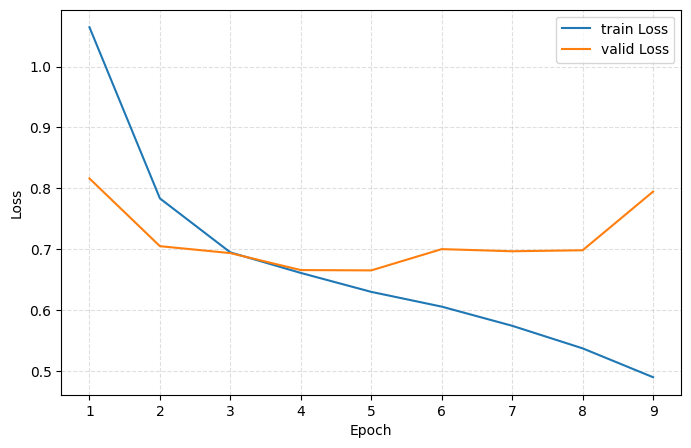

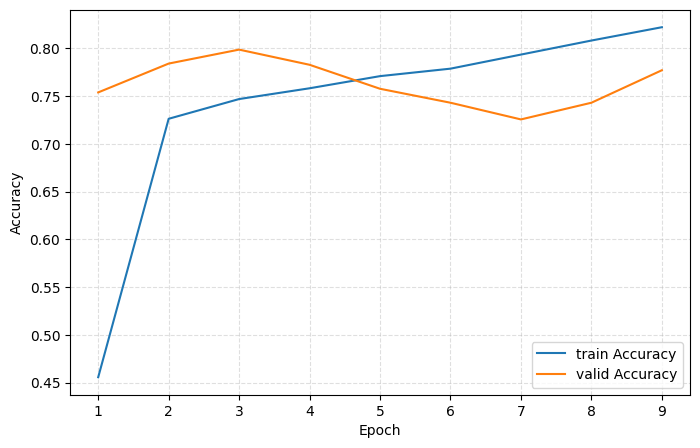

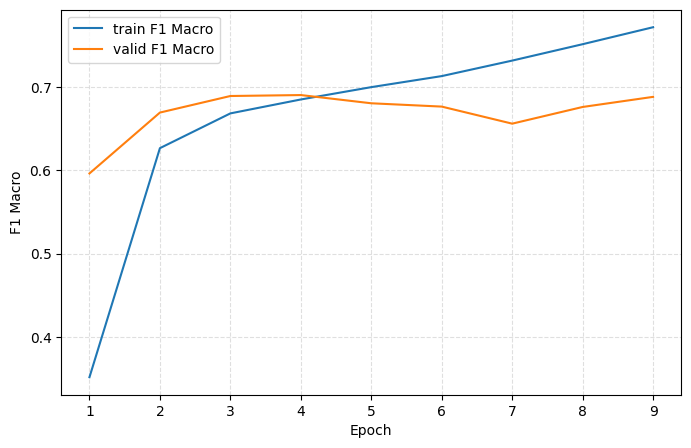

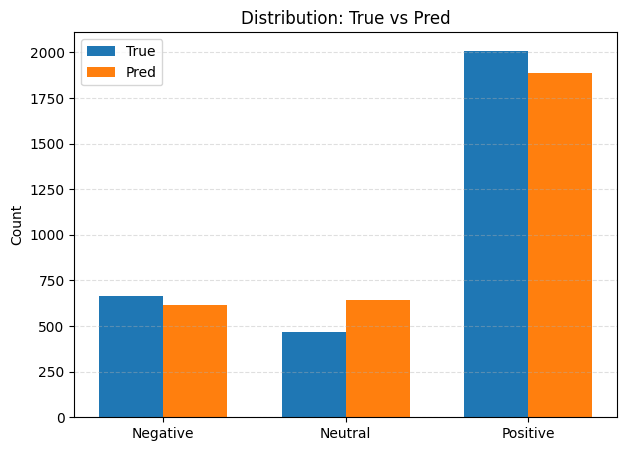

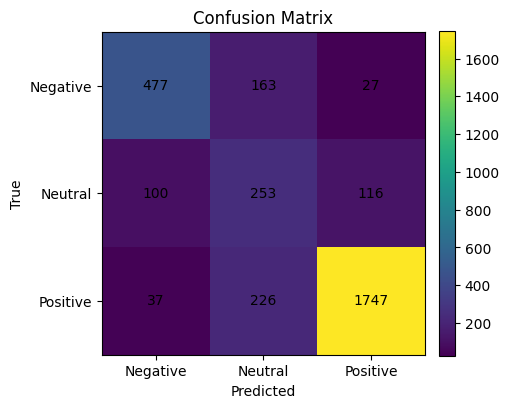

In [8]:
def eval_loader(loader, title="Test"):
    model.eval(); ys, ps = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(device, non_blocking=True)
            mask = batch["attention_mask"].to(device, non_blocking=True)
            y    = batch["labels"].to(device, non_blocking=True)
            out  = model(input_ids=ids, attention_mask=mask)
            ys.append(y.cpu().numpy()); ps.append(out.logits.argmax(-1).cpu().numpy())
    y_true = np.concatenate(ys); y_pred = np.concatenate(ps)
    true_cnt = np.bincount(y_true, minlength=3); pred_cnt = np.bincount(y_pred, minlength=3)
    print(f"\n=== {title.upper()} ===")
    print("True:", dict(zip(LABELS, true_cnt.tolist())))
    print("Pred:", dict(zip(LABELS, pred_cnt.tolist())))
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2]); print("\nCM:\n", cm)
    print("\nReport:\n", classification_report(y_true, y_pred, target_names=LABELS, digits=4, zero_division=0))
    return y_true, y_pred, cm, true_cnt, pred_cnt

y_true, y_pred, cm, true_cnt, pred_cnt = eval_loader(test_loader, "Test")

def plot_lines(y_tr, y_va, ylabel):
    xs = list(range(1, len(y_va)+1))
    plt.figure(figsize=(8,5))
    if y_tr is not None: plt.plot(xs, y_tr, label=f"train {ylabel}")
    plt.plot(xs, y_va, label=f"valid {ylabel}")
    plt.xlabel("Epoch"); plt.ylabel(ylabel); plt.xticks(xs); plt.grid(True, ls="--", alpha=0.4); plt.legend(); plt.show()

plot_lines(train_losses, valid_losses, "Loss")
plot_lines(train_accs,  valid_accs,  "Accuracy")
plot_lines(train_f1s,   valid_f1s,   "F1 Macro")

# Bar True vs Pred
x = np.arange(len(LABELS)); width = 0.35
plt.figure(figsize=(7,5))
plt.bar(x - width/2, true_cnt, width, label="True")
plt.bar(x + width/2, pred_cnt, width, label="Pred")
plt.xticks(x, LABELS); plt.ylabel("Count"); plt.title("Distribution: True vs Pred")
plt.legend(); plt.grid(axis="y", linestyle="--", alpha=0.4); plt.show()

# Confusion Matrix (matplotlib)
fig, ax = plt.subplots(figsize=(5.2,4.8))
im = ax.imshow(cm, interpolation='nearest'); ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_xticks([0,1,2]); ax.set_xticklabels(LABELS)
ax.set_yticks([0,1,2]); ax.set_yticklabels(LABELS)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]): ax.text(j, i, cm[i, j], ha="center", va="center")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()


Dự đoán nhanh (1 câu / danh sách / CSV)

In [12]:
def predict_one(text):
    model.eval()
    txt = normalize_text(text)
    enc = tokenizer([txt], truncation=True, padding=True, max_length=MAX_LEN, return_tensors="pt")
    with torch.no_grad():
        probs = F.softmax(model(input_ids=enc["input_ids"].to(device),
                                attention_mask=enc["attention_mask"].to(device)).logits, dim=-1
                         ).cpu().numpy().flatten()
    return LABELS[int(probs.argmax())], dict(zip(LABELS, probs.round(4).tolist()))

def predict_list(texts, batch_size=64):
    model.eval(); outs=[]
    for i in range(0, len(texts), batch_size):
        chunk = [normalize_text(t) for t in texts[i:i+batch_size]]
        enc = tokenizer(chunk, truncation=True, padding=True, max_length=MAX_LEN, return_tensors="pt")
        with torch.no_grad():
            pred = model(input_ids=enc["input_ids"].to(device),
                         attention_mask=enc["attention_mask"].to(device)).logits.argmax(-1).cpu().numpy().tolist()
        outs += [LABELS[p] for p in pred]
    return outs

demo = ["phòng học sạch sẽ, trang thiết bị tốt :)", "tôi đang dùng iphone 5s chữa cháy còn marphone là 6s vàng hồng.", "quá tệ và ồn ào @@"]

print(predict_one("giảng viên nhiệt tình nhưng phòng học hơi nóng :("))
print(list(zip(demo, predict_list(demo))))
print("Best model path:", os.path.join(OUT_DIR, "xlmr_sent3_best.pth"))
def demo_examples():
    demo = [
        "phòng học sạch sẽ, trang thiết bị tốt :)",
        "tôi đang dùng iphone 5s chữa cháy còn marphone là 6s vàng hồng.",
        "quá tệ và ồn ào @@ 😡",
        "mk ko thik môn này ^^",
        "trc giờ dc hỗ trợ rất nhiều <3",
        "bài giảng hay qa nhưng lớp đông quá :("
    ]

    print("\n=== DEMO ONE ===")
    text = "giảng viên nhiệt tình nhưng phòng học hơi nóng :("
    print("TEXT:", text)
    pred, prob = predict_one(text)
    print("PRED:", pred, "| PROBS:", prob)

    print("\n=== DEMO LIST ===")
    preds = predict_list(demo)
    for t, p in zip(demo, preds):
        print(f"- {t}\n  → {p}")

    print("\nBest model path:", os.path.join(OUT_DIR, "xlmr_sent3_best.pth"))


('Neutral', {'Negative': 0.06930000334978104, 'Neutral': 0.7412999868392944, 'Positive': 0.18950000405311584})
[('phòng học sạch sẽ, trang thiết bị tốt :)', 'Positive'), ('tôi đang dùng iphone 5s chữa cháy còn marphone là 6s vàng hồng.', 'Neutral'), ('quá tệ và ồn ào @@', 'Negative')]
Best model path: /content/xlmr_sent3_out/xlmr_sent3_best.pth


In [13]:
demo_examples()



=== DEMO ONE ===
TEXT: giảng viên nhiệt tình nhưng phòng học hơi nóng :(
PRED: Neutral | PROBS: {'Negative': 0.06930000334978104, 'Neutral': 0.7412999868392944, 'Positive': 0.18950000405311584}

=== DEMO LIST ===
- phòng học sạch sẽ, trang thiết bị tốt :)
  → Positive
- tôi đang dùng iphone 5s chữa cháy còn marphone là 6s vàng hồng.
  → Neutral
- quá tệ và ồn ào @@ 😡
  → Negative
- mk ko thik môn này ^^
  → Negative
- trc giờ dc hỗ trợ rất nhiều <3
  → Positive
- bài giảng hay qa nhưng lớp đông quá :(
  → Neutral

Best model path: /content/xlmr_sent3_out/xlmr_sent3_best.pth


In [11]:
# === ONE-CELL EXPORT & DOWNLOAD ===
import os, glob, torch, json
from transformers import AutoTokenizer, AutoModelForSequenceClassification

CKPT = "xlm-roberta-base"                 # checkpoint gốc
LABELS = ["Negative","Neutral","Positive"]
SAVE_DIR = "/content/xlmr_artifacts"      # nơi gom artifact
os.makedirs(SAVE_DIR, exist_ok=True)

# 1) Lấy model/tokenizer:
try:
    _ = model, tokenizer
except NameError:
    model = AutoModelForSequenceClassification.from_pretrained(
        CKPT, num_labels=3,
        id2label={i:l for i,l in enumerate(LABELS)},
        label2id={l:i for i,l in enumerate(LABELS)}
    )
    tokenizer = AutoTokenizer.from_pretrained(CKPT, use_fast=True)
    pth_candidates = glob.glob("/content/*.pth") + glob.glob("/content/**/*.pth", recursive=True)
    if pth_candidates:
        print("Found .pth:", pth_candidates[0])
        state = torch.load(pth_candidates[0], map_location="cpu")
        model.load_state_dict(state, strict=True)

# 2) Lưu theo định dạng save_pretrained
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
with open(os.path.join(SAVE_DIR, "labels.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(LABELS) + "\n")

# 3) Nén thành .zip và tải về
!cd /content && zip -r xlmr_artifacts.zip xlmr_artifacts -q
from google.colab import files
files.download("/content/xlmr_artifacts.zip")

print("DONE → /content/xlmr_artifacts.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DONE → /content/xlmr_artifacts.zip
